In [18]:
import os
import math
import pandas as pd
from datetime import datetime, timedelta
from astropy.io import fits

# Folder containing FITS files
folder_path = 'C:/Users/Observatory/Exo/Data/Standard-stars/BD302428B/2025-05-14/BD+302428B'

# Lists to collect extracted data
frame_names = []
filters = []
modes = []
exposure_times = []
starts = []
utcs = []


def utc_time_from_iso(iso_string):
    """Converts an ISO format datetime string to UTC time."""
    try:
        dt_obj = datetime.fromisoformat(iso_string)
        utc_time = dt_obj - timedelta(hours=3, minutes=30)  # Subtract for UTC
        return utc_time.strftime('%H:%M:%S.000')  # Only time
    except ValueError:
        return None


# Loop through all FITS files in the folder
for filename in os.listdir(folder_path):
    if filename.endswith('.fit'):
        try:
            filepath = os.path.join(folder_path, filename)
            with fits.open(filepath) as hdul:
                header = hdul[0].header

                # Frame name
                frame_names.append(filename)

                # Extract filter from FITS header
                filter_value = header.get('FILTER')
                filters.append(filter_value if filter_value is not None else None)

                # Extract mode from filename based on known keywords
                mode_keywords = ["High", "Low", "Merge"]
                mode_found = None
                for keyword in mode_keywords:
                    if keyword.lower() in filename.lower():
                        mode_found = keyword
                        break
                modes.append(mode_found)

                # Extract exposure time (EXPTIME in 10 µs units → convert to seconds)
                exptime_units = header.get('EXPTIME')
                if exptime_units is not None:
                    exptime_seconds = exptime_units * 1e-5  # Convert to seconds
                    exptime_seconds = round(exptime_seconds)  # Round to nearest integer second
                else:
                    exptime_seconds = None
                exposure_times.append(exptime_seconds)

                # Extract start time from header
                start = header.get('DATE-OBS')
                if start:
                    start = start.replace(" NOGPS", "")  # Clean up if necessary
                    try:
                        start_time = datetime.fromisoformat(start).strftime('%H:%M:%S.000')
                        starts.append(start_time)
                    except ValueError:
                        starts.append(None)
                else:
                    starts.append(None)

                # Convert to UTC
                utcs.append(utc_time_from_iso(start) if start else None)

        except Exception as e:
            print(f"Error processing file {filename}: {e}")
            frame_names.append(filename)
            filters.append(None)
            modes.append(None)
            exposure_times.append(None)
            starts.append(None)
            utcs.append(None)


# Create DataFrame
df = pd.DataFrame({
    'Frame Name': frame_names,
    'Filter': filters,
    'Mode': modes,
    'ExposureTime (s)': exposure_times,
    'Start': starts,
    'UTC': utcs
})

# Print to screen
print(df)

# Save DataFrame to CSV (overwrite existing)
csv_file_path = os.path.join(folder_path, "frames-report.csv")
df.to_csv(csv_file_path, index=False, mode='w', header=True)

print(f"DataFrame saved to: {csv_file_path}")


                                            Frame Name Filter   Mode  \
0    g_2025_05_14_3x3_-10.0C_exp00.00.01.000_High_1...      g   High   
1    g_2025_05_14_3x3_-10.0C_exp00.00.01.000_High_2...      g   High   
2    g_2025_05_14_3x3_-10.0C_exp00.00.01.000_High_3...      g   High   
3    g_2025_05_14_3x3_-10.0C_exp00.00.01.000_High_4...      g   High   
4    g_2025_05_14_3x3_-10.0C_exp00.00.01.000_High_5...      g   High   
..                                                 ...    ...    ...   
562  r_2025_05_15_3x3_-10.0C_exp00.00.05.000_Low_2.fit      r    Low   
563  r_2025_05_15_3x3_-10.0C_exp00.00.05.000_Low_3.fit      r    Low   
564  r_2025_05_15_3x3_-10.0C_exp00.00.05.000_Merge_...      r  Merge   
565  r_2025_05_15_3x3_-10.0C_exp00.00.05.000_Merge_...      r  Merge   
566  r_2025_05_15_3x3_-10.0C_exp00.00.05.000_Merge_...      r  Merge   

     ExposureTime (s)         Start           UTC  
0                   1  22:42:07.000  19:12:07.000  
1                   1  22:45:38

C:\Users\Observatory\AppData\Local\Temp\ipykernel_6204\3559251047.py:83: FutureWarning: Parsed string "2025-05-14T22:42:07.124 NOGPS" included an un-recognized timezone "NOGPS". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  df['Datetime'] = pd.to_datetime(df['Start'], errors='coerce')


Detected filters: ['g', 'i', 'r']
Plot saved to: C:/Users/Observatory/Exo/Data/Standard-stars/BD302428B/2025-05-14/BD+302428B\g_2025-05-13_exposure_times_plot.png


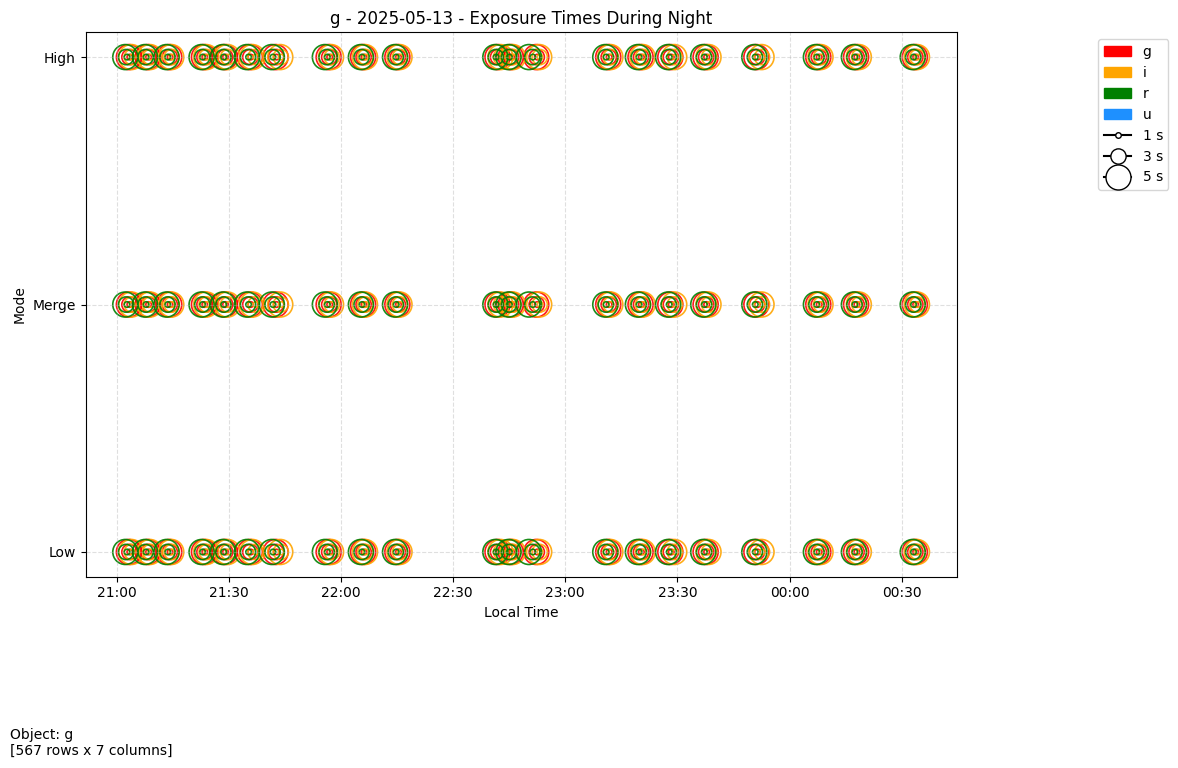

In [20]:

# --- Configurations ---
dateobs = "2025-05-13"
folder_path = r'C:/Users/Observatory/Exo/Data/Standard-stars/BD302428B/2025-05-14/BD+302428B'
known_modes = ['Low', 'High', 'Merge']
filter_colors = {'g': 'red', 'i': 'orange', 'r': 'green', 'u': 'dodgerblue'}
mode_mapping = {'Low': 0, 'High': 1, 'Merge': 0.5}

# --- Utility Functions ---
def utc_time_from_iso(iso_string):
    try:
        dt = datetime.fromisoformat(iso_string.replace(" NOGPS", ""))
        return (dt - timedelta(hours=3, minutes=30)).strftime('%H:%M:%S.000')
    except:
        return None

def extract_filter(fname):
    parts = fname.split('_')
    for part in parts:
        if part.lower() in filter_colors:
            return part.lower()
    return None

def extract_mode(fname):
    for mode in known_modes:
        if mode.lower() in fname.lower():
            return mode
    return None

# --- Data Collection ---
records = []
for fname in os.listdir(folder_path):
    if not fname.lower().endswith('.fit'):
        continue

    try:
        with fits.open(os.path.join(folder_path, fname)) as hdul:
            hdr = hdul[0].header
            exptime = hdr.get('EXPTIME')
            start = hdr.get('DATE-OBS')

            # --- Extract filter from FITS header ---
            filter_from_header = hdr.get('FILTER')
            if isinstance(filter_from_header, str):
                filter_from_header = filter_from_header.strip().lower()
                if filter_from_header not in filter_colors:
                    filter_from_header = None

            # Fallback to filename if header missing or invalid
            if not filter_from_header:
                filter_from_header = extract_filter(fname)

            # --- Extract observing mode ---
            mode = extract_mode(fname)

            # --- Add record ---
            records.append({
                'Frame Name': fname,
                'Filter': filter_from_header,
                'Mode': mode,
                'ExposureTime': math.ceil(exptime / 100000) if exptime else None,
                'Start': start,
                'UTC': utc_time_from_iso(start) if start else None
            })

    except Exception as e:
        print(f"Error processing {fname}: {e}")
        records.append({
            'Frame Name': fname,
            'Filter': None,
            'Mode': None,
            'ExposureTime': None,
            'Start': None,
            'UTC': None
        })

# --- Create DataFrame ---
df = pd.DataFrame(records)

# --- Extract object name ---
object_name = df['Frame Name'].iloc[0].split('_')[0] if not df.empty else "UnknownObject"

# --- Prepare plotting variables ---
df['Datetime'] = pd.to_datetime(df['Start'], errors='coerce')
x = df['Datetime']
y = df['Mode'].map(mode_mapping).fillna(-1)
colors = df['Filter'].map(filter_colors).fillna('gray')
radii = df['ExposureTime'].fillna(0)

# --- Debug print for filters ---
print("Detected filters:", sorted(df['Filter'].dropna().unique()))

# --- Plotting ---
plt.figure(figsize=(12, 8))

# Normalize marker sizes
min_size, max_size = 4, 18
if radii.max() > radii.min():
    size_scale = ((radii - radii.min()) / (radii.max() - radii.min()) * (max_size - min_size) + min_size)
else:
    size_scale = pd.Series([min_size]*len(radii))

plt.scatter(
    x, y, s=size_scale**2, facecolors='none', edgecolors=colors, linewidths=1.2, alpha=0.9
)


# Axis formatting
plt.xlabel("Local Time")
plt.ylabel("Mode")
plt.title(f"{object_name} - {dateobs} - Exposure Times During Night")
plt.yticks(list(mode_mapping.values()), list(mode_mapping.keys()))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.grid(True, linestyle='--', alpha=0.4)

# Legends
filter_patches = [mpatches.Patch(color=c, label=f) for f, c in filter_colors.items()]
size_values = [radii.min(), radii.median(), radii.max()]
size_labels = [f"{int(s)} s" for s in size_values if not pd.isna(s)]
size_patches = [
    plt.Line2D([0], [0], marker='o', color='black', markerfacecolor='white',
               markersize=((s - radii.min()) / (radii.max() - radii.min()) * (max_size - min_size) + min_size),
               label=l)
    for s, l in zip(size_values, size_labels)
]
plt.legend(handles=filter_patches + size_patches, loc='upper right', bbox_to_anchor=(1.25, 1))

# Footer text
plt.figtext(0.01, -0.05, f"Object: {object_name}\n[{df.shape[0]} rows x {df.shape[1]} columns]",
             ha='left', fontsize=10)
plt.tight_layout(rect=[0, 0.1, 1, 0.9])

# Save & show
plot_path = os.path.join(folder_path, f"{object_name}_{dateobs}_exposure_times_plot.png")
plt.savefig(plot_path, bbox_inches='tight', dpi=300)
print(f"Plot saved to: {plot_path}")
plt.show()